# Lab 6

Lo primero que vamos a hacer es cargar los datos, con esto convertimos los json a columnas y luego los cargamos, una cosa los json hijos tendran esta estructura `padre_hijo`

In [74]:
import json
import pandas as pd
import nltk
import numpy as np
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS  # Opcional si quieres combinar
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import networkx as nx
from wordcloud import STOPWORDS as WC_STOPWORDS
import community as community_louvain
from collections import defaultdict


In [30]:

def load_json_lines_to_df(filepath, encoding="utf-16"):
    all_objs = []

    with open(filepath, "r", encoding=encoding) as f:
        for line_number, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                # Convertir el JSON de la línea a diccionario
                obj = json.loads(line)
                all_objs.append(obj)
            except json.JSONDecodeError as e:
                print(f"⚠️ Error JSON en línea {line_number}: {e}")
                # Opcional: guardar la línea completa como string para revisarla
                all_objs.append({"raw_line": line})

    # Normalizar JSON, aplastando diccionarios anidados
    df = pd.json_normalize(all_objs, sep='_', errors='ignore')

    return df

# Cargar dataset
df_arevalo = load_json_lines_to_df("Data/tioberny.txt")



cols_to_show = ['id', 'rawContent', 'user_username', 'user_displayname']
print(df_arevalo[[c for c in cols_to_show if c in df_arevalo.columns]].head())


                    id                                         rawContent  \
0  1834281080029110288  _\nConfirmado Compañeres,\n\nEl impuesto por l...   
1  1834252464092069901  #URGENTE Lo que los medios #faferos no informa...   
2  1834280919336976681  @IvanDuque @BArevalodeLeon Con que usaste PEGA...   
3  1834280512933732694  @IvanDuque @BArevalodeLeon Entre Ellos se enti...   
4  1834279986254987428  El presidente @BArevalodeLeon y la vicepreside...   

    user_username        user_displayname  
0  La_ReVoluZzion      The_ReVoluZZzioN 🫡  
1      XelaNewsGt                XelaNews  
2       M24095273  VIVAlafuenteDEtodaVIDA  
3    carlosalbesc  Carlos Alberto Escobar  
4      Brenda_AGN             Brenda Lari  


In [31]:
df_arevalo.columns

Index(['id', 'id_str', 'url', 'date', 'lang', 'rawContent', 'replyCount',
       'retweetCount', 'likeCount', 'quoteCount',
       ...
       'quotedTweet_quotedTweet_inReplyToTweetIdStr',
       'quotedTweet_quotedTweet_inReplyToUser',
       'quotedTweet_quotedTweet_source', 'quotedTweet_quotedTweet_sourceUrl',
       'quotedTweet_quotedTweet_sourceLabel',
       'quotedTweet_quotedTweet_media_photos',
       'quotedTweet_quotedTweet_media_videos',
       'quotedTweet_quotedTweet_media_animated',
       'quotedTweet_quotedTweet_card', 'quotedTweet_quotedTweet__type'],
      dtype='object', length=203)

## Limpieza

Lo que vamos a hacer es limpiar los datos. haciendo pipeline de limpieza que usamos en nuestros labs anteriores

In [32]:

# Descargar stopwords en español de NLTK
nltk.download('stopwords')

# Stopwords completas en español de NLTK
stop_words = set(stopwords.words('spanish'))



# Actualizamos stop_words

# Números permitidos en tweets
allowed_numbers = {"1945", "911", "2008", "2014", "1980", "2013", "2016", "2011"}



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ppguz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
def convert_to_lower(word): #Convierte a minúsculas
    return word.lower()

def remove_special_characters(word): #Remueve comillas. arrobas y hashtagas
    return word.replace("#", "").replace("@", "").replace("'", "")

def remove_url(word): #Busca urls y las remueve
    text = re.sub(r'http\S+|www\S+|https\S+', '', word)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_emojis(word): #Busca emojis y los borra
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F" 
        "\U0001F300-\U0001F5FF" 
        "\U0001F680-\U0001F6FF" 
        "\U0001F1E0-\U0001F1FF"  
        "\U00002700-\U000027BF"  
        "\U0001F900-\U0001F9FF"  
        "\U00002600-\U000026FF"  
        "\U00002B00-\U00002BFF" 
        "\U0001FA70-\U0001FAFF" 
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', word).strip()

# Función para limpiar el texto
import re

def clean_text(text):
    text = str(text).lower()
    text = remove_url(text)
    text = remove_emojis(text)
    text = remove_special_characters(text)
    text = remove_unwanted_numbers(text)
    
    # Quitar puntuación pero mantener espacios
    text = re.sub(r'[^\w\s]', '', text)
    
    # Tokenizar por espacios
    tokens = text.split()
    
    # Eliminar stopwords solo si la palabra completa coincide
    tokens = [word for word in tokens if word in allowed_numbers or word not in stop_words]
    
    return " ".join(tokens)



def extract_numbers(text):
    return re.findall(r'\d+', str(text)) #busca y extrae números en el dataset

def count_words(dataset, column): #Esta función cuenta las palabras en cada tweet
    all_words = ''
    for i in dataset[column]:
        all_words = all_words + i + ' '

    all_words = all_words.split()

    frequency = Counter(all_words)

    print("{:<10} {:<10}".format("Palabra", "Frecuencia"))
    print("-" * 20)
    for palabra, freq in frequency.most_common():
        print("{:<10} {:<10}".format(palabra, freq))

def remove_unwanted_numbers(text): #Remueve números que no son permitidos en los tweets
    return re.sub(r'\b(?!' + '|'.join(allowed_numbers) + r')\d+\b', '', str(text))

def get_words(text_series): #Obtener y separar palabras por tweet
    words = []
    for text in text_series:
        words.extend(str(text).split())  
    return words
def remove_users(text):
    return re.sub(r"@\w+", "", text)


In [34]:
df_arevalo['rawContent'] = df_arevalo['rawContent'].apply(remove_users)
df_arevalo['rawContent'] = df_arevalo['rawContent'].astype(str).apply(convert_to_lower)
df_arevalo['rawContent'] = df_arevalo['rawContent'].astype(str).apply(remove_special_characters)
df_arevalo['rawContent'] = df_arevalo['rawContent'].astype(str).apply(remove_url)
df_arevalo['rawContent'] = df_arevalo['rawContent'].astype(str).apply(remove_emojis)


df_arevalo["rawContent"] = df_arevalo["rawContent"].apply(clean_text)


df_arevalo["rawContent"] = df_arevalo["rawContent"].apply(remove_unwanted_numbers)

df_arevalo["rawContent"].head()


0    _ confirmado compañeres impuesto solo cuenta p...
1    urgente medios faferos informaron ayer acerca ...
2    usaste pegasus espiar detractores obra narcisi...
3           entienden bien cuadrando productivareunión
4    presidente vicepresidenta participan sesión so...
Name: rawContent, dtype: object

Ahora creamos el dataframe para usarlo como un grafo

In [35]:
edges = []
for i, row in df_arevalo.iterrows():
    author = row["user_username"]   # el autor del tweet
    
    # --- 1. Menciones. ---
    if isinstance(row["mentionedUsers"], list):
        for u in row["mentionedUsers"]:
            edges.append({
                "source": author,
                "target": u["username"],
                "interaction": "mencion"
            })
    
    # --- 2. Reteweets (citados/retweeteados) ---
    if pd.notna(row.get("quotedTweet_user_username")):
        edges.append({
            "source": author,
            "target": row["quotedTweet_user_username"],
            "interaction": "retewet"
        })
    
    if pd.notna(row.get("inReplyToTweetIdStr")):
        id_str = row["inReplyToTweetIdStr"]
        target_series = df_arevalo.loc[df_arevalo["id_str"] == id_str, "user_username"]
        if not target_series.empty:
            target = target_series.iloc[0] 
            edges.append({
                "source": author,
                "target": target,
                "interaction": "respuesta"
            })

df_graph = pd.DataFrame(edges)

print(df_graph.head(5))


           source          target interaction
0  La_ReVoluZzion  usembassyguate     mencion
1  La_ReVoluZzion  48CantonesToto     mencion
2  La_ReVoluZzion      USAIDGuate     mencion
3  La_ReVoluZzion     UEGuatemala     mencion
4  La_ReVoluZzion  BArevalodeLeon     mencion


## Analisis Exploratorio

### Estructura de Datos usada

De todo lo del dataframe solo nos importan estas cosas

- retewets
- contenido
- menciones
- respuestas

Asi que vamos a ver primero cada una

In [36]:
df_arevalo["mentionedUsers"].head()

0    [{'id': 23664866, 'id_str': '23664866', 'usern...
1                                                   []
2    [{'id': 77653794, 'id_str': '77653794', 'usern...
3    [{'id': 77653794, 'id_str': '77653794', 'usern...
4    [{'id': 945378369818058752, 'id_str': '9453783...
Name: mentionedUsers, dtype: object

Como podemos ver las menciones son de formato lista con jsons

In [38]:
df_arevalo[df_arevalo["quotedTweet_user_username"].notna()]["quotedTweet_user_username"].head(5)


0       XelaNewsGt
10    GuatemalaGob
16    GuatemalaGob
21    GuatemalaGob
25       ElQueNews
Name: quotedTweet_user_username, dtype: object

In [39]:
df_arevalo[df_arevalo["quotedTweet_rawContent"].notna()]["quotedTweet_rawContent"].head(5)


0     #URGENTE Lo que los medios #faferos no informa...
10    🔴 |  El presidente @BArevalodeLeon participa e...
16    🔴 |  El presidente @BArevalodeLeon participa e...
21    🔴 |  El presidente @BArevalodeLeon participa e...
25    #URGENTE El gobierno de Bernardo Arévalo pierd...
Name: quotedTweet_rawContent, dtype: object

In [40]:
df_arevalo[df_arevalo["retweetedTweet"].notna()]["retweetedTweet"].head(5)


Series([], Name: retweetedTweet, dtype: object)

Ese es el retewet (quotedTweet_rawContent), ya que retweetedTweet parece ser algo que ya no tiene nada, talvez lo quitaron en toda la db y la dejaron de usar

Recordemos que teweter hasta las respuestas son twwets por lo que esto quiere decir que lo unico que debemos de hacer es ver si inReplyToUser, que seria el campo con la info de los usuario que hizo repli osea respondio

In [41]:
df_arevalo[df_arevalo["inReplyToUser"].notna()]["inReplyToUser"].head(5)


Series([], Name: inReplyToUser, dtype: float64)

no funciono probaremos con otros reply

In [42]:
df_arevalo[df_arevalo["inReplyToTweetId"].notna()]["inReplyToTweetId"].head(5)


2    1.834197e+18
3    1.834197e+18
5    1.833556e+18
6    1.834271e+18
7    1.834197e+18
Name: inReplyToTweetId, dtype: float64

In [43]:
df_arevalo[df_arevalo["inReplyToTweetIdStr"].notna()]["inReplyToTweetIdStr"].head(5)


2    1834197215415599186
3    1834197215415599186
5    1833556390192824324
6    1834271430994804795
7    1834197215415599186
Name: inReplyToTweetIdStr, dtype: object

Podemos ver que tambien inReplyToUser se dejo de usar, asi que las respuestas son a los  ids del twett.

### Exploracion de datos

🔎 Información general
Total de tweets: 5019
Usuarios únicos: 2620
Tweets promedio por usuario: 1.92

📌 Interacciones
Respuestas: 4276
Retweets: 295

👥 Menciones
Top 10 cuentas mencionadas:
 - BArevalodeLeon: 4830 menciones
 - GuatemalaGob: 915 menciones
 - UbaldoMacu: 574 menciones
 - santipalomov: 528 menciones
 - MPguatemala: 466 menciones
 - FJimenezmingob: 403 menciones
 - mingobguate: 291 menciones
 - __VaderTG: 273 menciones
 - CongresoGuate: 254 menciones
 - DiariodeCA: 219 menciones

🏷️ Hashtags
Top 5 hashtags:
 - #URGENTE: 26 veces
 - #GuatemalaSaleAdelante: 25 veces
 - #MinfinSaleAdelante: 17 veces
 - #Guatemala: 15 veces
 - #Presupuesto2025: 14 veces


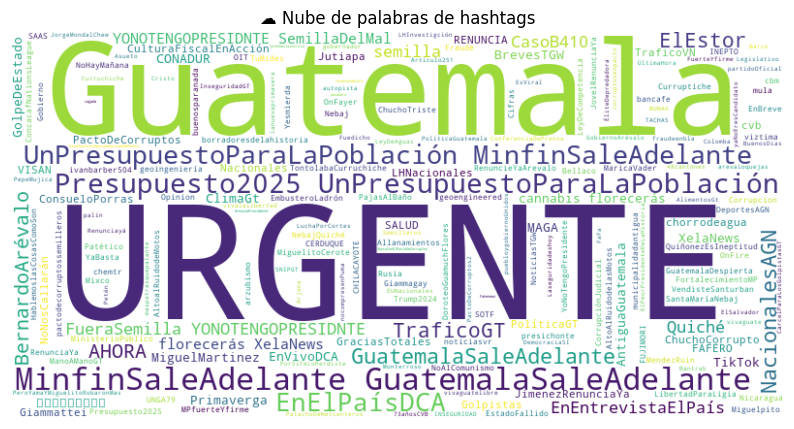

In [45]:


# 1. Información general del dataset
print("🔎 Información general")
print(f"Total de tweets: {df_arevalo.shape[0]}")
print(f"Usuarios únicos: {df_arevalo['user_username'].nunique()}")
print(f"Tweets promedio por usuario: {df_arevalo.shape[0] / df_arevalo['user_username'].nunique():.2f}")
print()

print("📌 Interacciones")
num_respuestas = df_arevalo["inReplyToTweetId"].notna().sum()

num_quoted = df_arevalo["quotedTweet_rawContent"].notna().sum()

print(f"Respuestas: {num_respuestas}")
print(f"Retweets: {num_quoted}")
print()

print("👥 Menciones")
if "mentionedUsers" in df_arevalo.columns:
    menciones = sum(df_arevalo["mentionedUsers"].dropna().tolist(), [])
    menciones_usernames = [m['username'] for m in menciones if isinstance(m, dict) and 'username' in m]
    top_menciones = Counter(menciones_usernames).most_common(10)
    print("Top 10 cuentas mencionadas:")
    for user, count in top_menciones:
        print(f" - {user}: {count} menciones")
else:
    print("⚠️ No se encontró columna 'mentionedUsers'")
print()

# 4. Hashtags
print("🏷️ Hashtags")
if "hashtags" in df_arevalo.columns:
    hashtags = sum(df_arevalo["hashtags"].dropna().tolist(), [])
    top_hashtags = Counter(hashtags).most_common(5)
    print("Top 5 hashtags:")
    for tag, count in top_hashtags:
        print(f" - #{tag}: {count} veces")

    texto = " ".join(hashtags)
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(texto)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("☁️ Nube de palabras de hashtags")
    plt.show()
else:
    print("⚠️ No se encontró columna 'hashtags'")
print()





Basado en esto proponemos las siguientes preguntas. 


#### 1. ¿Cómo evoluciona la intensidad del discurso político en el tiempo?

C:\Users\ppguz\AppData\Local\Temp\ipykernel_27640\263886199.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["interacciones"] = (


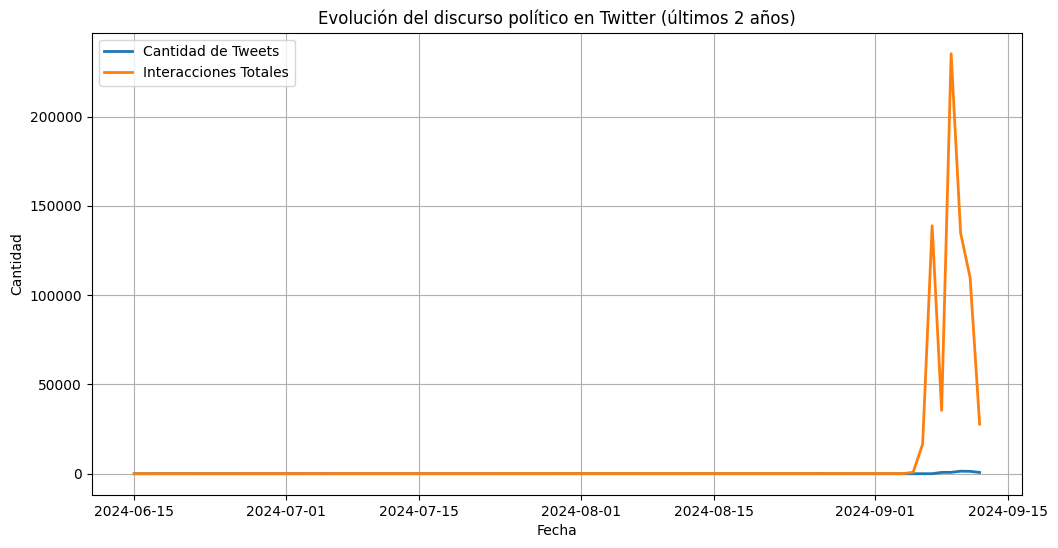

In [46]:
# Convertir columna 'date' a datetime con timezone UTC
df_arevalo["date"] = pd.to_datetime(df_arevalo["date"], utc=True)

# Crear columna 'fecha' (solo día)
df_arevalo["fecha"] = df_arevalo["date"].dt.date

# Fechas de corte
hoy = pd.Timestamp.today(tz="UTC")
inicio = pd.Timestamp(year=hoy.year - 1, month=1, day=1, tz="UTC")
fin = pd.Timestamp(year=hoy.year, month=12, day=31, tz="UTC")

# Filtrar dataset entre esas fechas
df_filtrado = df_arevalo[(df_arevalo["date"] >= inicio) & (df_arevalo["date"] <= fin)]

# Agrupar tweets por día
tweets_por_dia = df_filtrado.groupby("fecha").size()

# Calcular interacciones
df_filtrado["interacciones"] = (
    df_filtrado["likeCount"] 
    + df_filtrado["retweetCount"] 
    + df_filtrado["replyCount"] 
    + df_filtrado["quoteCount"]
)

interacciones_por_dia = df_filtrado.groupby("fecha")["interacciones"].sum()

# Gráfico
plt.figure(figsize=(12,6))
tweets_por_dia.plot(label="Cantidad de Tweets", linewidth=2)
interacciones_por_dia.plot(label="Interacciones Totales", linewidth=2)

plt.title("Evolución del discurso político en Twitter (últimos 2 años)")
plt.xlabel("Fecha")
plt.ylabel("Cantidad")
plt.legend()
plt.grid(True)
plt.show()


Se observa que la actividad de los tweets con carga política aumenta significativamente en septiembre de 2024. Este repunte coincide con el mes de las fiestas patrias en Guatemala, donde los temas de identidad nacional, manifestaciones sociales y mensajes políticos suelen intensificarse.
Además, la coyuntura política del momento (como críticas al gobierno o menciones a instituciones internacionales) también pudo haber contribuido a este aumento de interacciones.

#### 2. ¿Qué actores (usuarios mencionados) concentran el mayor numero de retwets, y que influye en su presencia?

In [47]:
print("💬 Usuarios más citados en quoted tweets")
if "quotedTweet_user_displayname" in df_arevalo.columns:
    top_citados = df_arevalo["quotedTweet_user_displayname"].dropna().value_counts().head(10)
    print(top_citados)

💬 Usuarios más citados en quoted tweets
quotedTweet_user_displayname
VueloLibreGt                17
Gobierno Guatemala          11
Prensa Comunitaria Km169    10
El Quetzal News              9
¡Yes, Master!                8
Josefina Peralta             8
XelaNews                     7
Bernardo Arévalo             7
Ubaldo Macú                  7
Soy 502                      5
Name: count, dtype: int64


Podemos ver que esta es la cantidad de actores mas citados sus tweets, la gran mayoria carga un discurso politico detras.

Cabe  ver que una gran parte son las noticias, esto debido a que muchos usuarios hacen comentarios retweeeteando el contenido de las mismas. Hay cuentas de gobierno , las cuales muy posiblemente son debido a varias criticas al mismo. A Bernardo Arevalo , tales como comentarios o menciones a este. 

Pero hay algunas cuentas como Yes, Master, que se le ha señalado de realizar fuertes criticas al gobierno como tener toda una comunidad a difundir menciones al mismo. Lo cual muchas de las cuentas que se hacen referencia a el son parte de su comunidad

#### 3. ¿Qué temas o conceptos principales aparecen con mayor frecuencia en el contenido de los tweets (rawContent) y cómo influyen en la intensidad del discurso político?

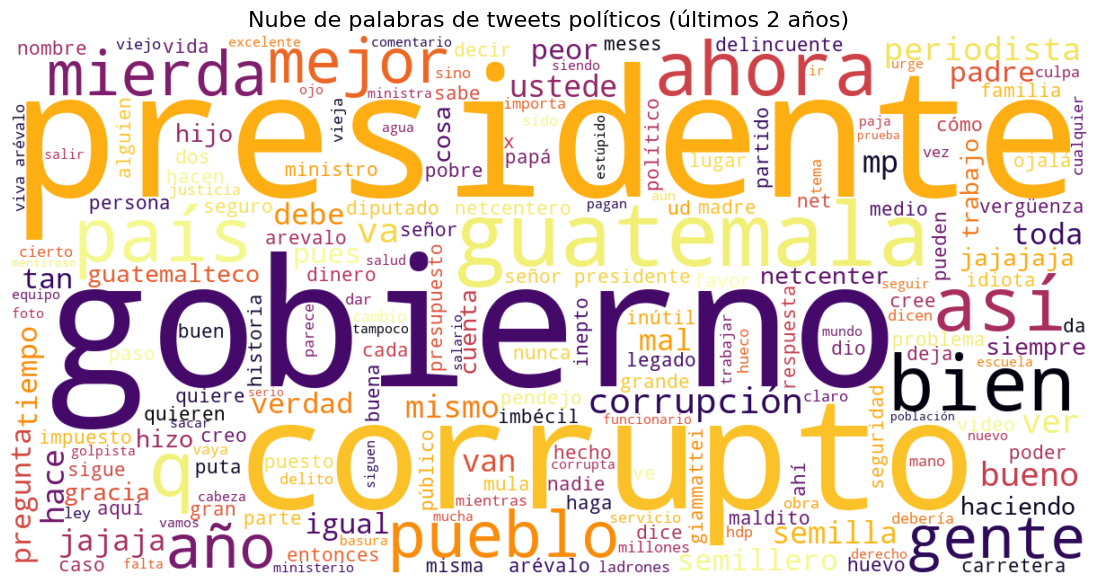

In [48]:


texto = " ".join(df_arevalo["rawContent"].dropna().astype(str).tolist())


stopwords = set(WC_STOPWORDS)
stopwords.update([
    "https", "co", "RT", "rt", "amp", "si", "no", "aqui", "ahi", "ese",
    "esto", "asi", "ser", "estar", "tener", "solo", "aun", "día",
    "hoy", "ayer", "mañana", "mas", "menos", "muy", "entre", "sobre", "ya",
    "tco", "xcom", "hacer", "puede", "usted", "vos", "sos"
])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stopwords,
    collocations=True,
    colormap="inferno"
).generate(texto)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de tweets políticos (últimos 2 años)", fontsize=16)
plt.show()


Podemos ver que la mayoria de palabras son cosas descalificativa como corrupto, mier**, corrupcion y una palabra muy importante ahi que es semillero. Ya que es un adjetivo calificativo de los miembros del partido semilla al cual pertenece Bernardo , con lo demas podemos observar que la mayoria son calificaciones depsectivas a su persona y al gobierno que tiene. Lo cual puede reflejar un descontento general , o talvez no ?.

Pues sucede que como se menciono anteriormente realmente no es tan fiable de seguir ello, pues en un periodo muy corto de tiempo, el conteo de adjetivos descalifictaviso se disparo, lo cual es un crecimiento anormal y poco comun en lo humano. Por lo que se requiere un analisis mas profundo para concluir esto

## Análisis de la topología de la red


Primero vamos a crear el grafo que represente las interacciones entre usuarios

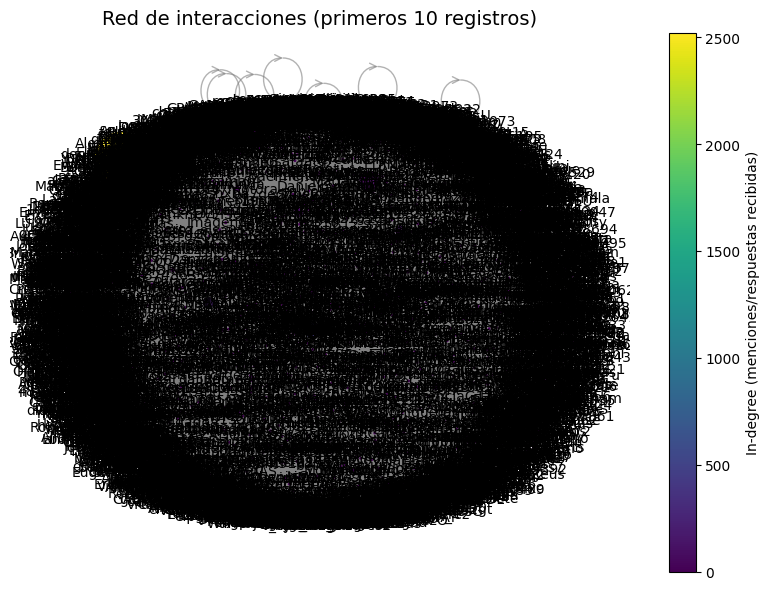

In [49]:

df_sample = df_graph

G = nx.from_pandas_edgelist(
    df_sample,
    source="source",
    target="target",
    edge_attr="interaction",
    create_using=nx.DiGraph()
)

in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
pagerank = nx.pagerank(G)

fig, ax = plt.subplots(figsize=(10, 7))

pos = nx.spring_layout(G, k=0.5, seed=42)

node_sizes = [8000 * pagerank[n] for n in G.nodes()]
node_colors = [in_degree[n] for n in G.nodes()]

nodes = nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    alpha=0.9,
    ax=ax
)
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=12, edge_color="gray", alpha=0.6, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_color="black", ax=ax)

sm = plt.cm.ScalarMappable(
    cmap=plt.cm.viridis,
    norm=plt.Normalize(vmin=min(in_degree.values()), vmax=max(in_degree.values()))
)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="In-degree (menciones/respuestas recibidas)")

ax.set_title("Red de interacciones (primeros 10 registros)", fontsize=14)
ax.axis("off")
plt.show()


Podemos ver que al ser todo el grafo no hay interacciones visibles por el numero descomunal de conexiones, asi que graficaremos uno que sea mas pequeño

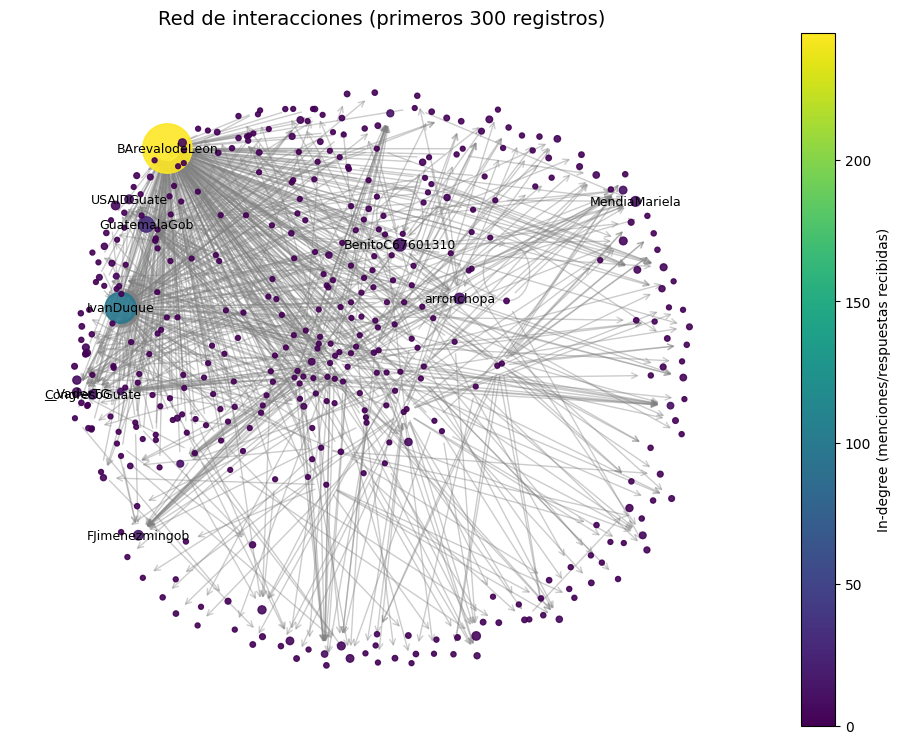

In [50]:

# --- 1. Usar los primeros 300 registros ---
df_sample300 = df_graph.head(1200)

# --- 2. Crear el grafo dirigido ---
G300 = nx.from_pandas_edgelist(
    df_sample300,
    source="source",
    target="target",
    edge_attr="interaction",
    create_using=nx.DiGraph()
)

# --- 3. Calcular métricas ---
in_degree_300 = dict(G300.in_degree())
out_degree_300 = dict(G300.out_degree())
pagerank_300 = nx.pagerank(G300)

# --- 4. Visualización ---
fig, ax = plt.subplots(figsize=(12, 9))

pos = nx.spring_layout(G300, k=0.4, seed=42)

node_sizes = [8000 * pagerank_300[n] for n in G300.nodes()]
node_colors = [in_degree_300[n] for n in G300.nodes()]

nodes = nx.draw_networkx_nodes(
    G300, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis,
    alpha=0.9,
    ax=ax
)
nx.draw_networkx_edges(G300, pos, arrowstyle="->", arrowsize=10, edge_color="gray", alpha=0.4, ax=ax)

# Etiquetas solo para los 10 más influyentes
top_labels = sorted(pagerank_300, key=pagerank_300.get, reverse=True)[:10]
nx.draw_networkx_labels(
    G300, pos,
    labels={n: n for n in top_labels},
    font_size=9, font_color="black", ax=ax
)

# Barra de color
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.viridis,
    norm=plt.Normalize(vmin=min(in_degree_300.values()), vmax=max(in_degree_300.values()))
)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="In-degree (menciones/respuestas recibidas)")

ax.set_title("Red de interacciones (primeros 300 registros)", fontsize=14)
ax.axis("off")
plt.show()


Podemos ver que los nodos más grandes y con tonalidades más intensas (amarillo/verde brillante en el grafo) corresponden a los usuarios que concentran más interacciones, ya sea porque son mencionados, retuiteados o reciben respuestas. Entre ellos destacan Emisoras Unidas, Iván Duque y Gobierno de Guatemala, que aparecen como actores con alta centralidad en la red. Sin embargo, el nodo más sobresaliente es Bernardo Arévalo, alrededor del cual gira gran parte de la conversación, dado que es el tema principal de los tweets recolectados. La presencia destacada del Gobierno de Guatemala también refleja que la discusión se enmarca en críticas, menciones o demandas hacia las instituciones oficiales. Esto sugiere que la red se organiza en torno a figuras políticas clave y medios de comunicación que amplifican o centralizan la conversación pública.

Ahora analizaremos las metricas de la red.

In [24]:


densidad = nx.density(G)

if nx.is_connected(G.to_undirected()):
    diametro = nx.diameter(G.to_undirected())
else:
    componente_gigante = max(nx.connected_components(G.to_undirected()), key=len)
    diametro = nx.diameter(G.subgraph(componente_gigante).to_undirected())


clustering = nx.average_clustering(G.to_undirected())

# --- Mostrar resultados ---
print(f"Densidad de la red: {densidad:.4f}")
print(f"Diámetro de la red: {diametro}")
print(f"Coeficiente de agrupamiento promedio: {clustering:.4f}")


Densidad de la red: 0.0013
Diámetro de la red: 6
Coeficiente de agrupamiento promedio: 0.3734



* **Densidad (0.0013):** Podemos ver que la densidad es muy baja, esto porque la mayoria de nodos no estan muy conectados. Es normal en redes sociales ya que se forman comunidades y no todos los nodos estan conectados entre otros

* **Diámetro (6):** La distancia mas larga entre nodos es de 6 , lo cual es bastante positivo, ya que si se quiere explorar relaciones mas profundas o sugerir con algoritmos a usuarios potenciales introducirlos a otras comunidades no es tan profundo la conexion. 

* **Coeficiente de agrupamiento (0.3734)** → Es relativamente alto, lo que quiere decir que los usuarios tienden a formar **grupos o clústeres** donde varios interactúan entre sí. Esto apunta a la existencia de comunidades temáticas (ejemplo: política guatemalteca, medios de comunicación, diplomacia internacional).  Esto esta muy relacionado con lo que se analiza que es sobre Bernardo Arevalo, y estas comunidades se orientan a la farandula, politica, noticias, etc


## Detección de comunidades

Ahora vamos a visualizar las comunidades en el grafo, para detectar las comunidades vamos a usar el algoritmo de Louvain pues el uno de los más famosos y es bastante eficiente.

In [ ]:
partition = community_louvain.best_partition(G.to_undirected(), weight='weight', random_state=42)
communities = defaultdict(list)
for n, c in partition.items():
    communities[c].append(n)


communities_sorted = sorted(communities.items(), key=lambda kv: len(kv[1]), reverse=True)
print(f"Comunidades detectadas: {len(communities_sorted)}")
for cid, nodes in communities_sorted[:5]:
    print(f"  Comunidad {cid}: {len(nodes)} nodos")


pagerank = nx.pagerank(G, weight='weight')

Comunidades detectadas: 19
  Comunidad 5: 897 nodos
  Comunidad 10: 333 nodos
  Comunidad 7: 326 nodos
  Comunidad 0: 257 nodos
  Comunidad 8: 198 nodos


AHora ya tenemos a las comunidades, vamos a ver cuales son las más relavantes, para eso vamos a analizar cuáles tienen a los influencers más relvantes, cuáles tienen más interacciones en promedio, etc. 

In [79]:

df_edges = (
    df_graph
    .groupby(["source", "target"])
    .size()   # cuenta cuántas veces aparece esa interacción
    .reset_index(name="weight")
)

def characterize_community(G, nodes, pagerank, df_edges):
    sub = G.subgraph(nodes).copy()
    internal_edges = df_edges[df_edges['source'].isin(nodes) & df_edges['target'].isin(nodes)]
    internal_weight_sum = internal_edges['weight'].sum() if len(internal_edges) else 0.0
    
    prs = [(n, pagerank.get(n, 0.0)) for n in nodes]
    prs.sort(key=lambda x: x[1], reverse=True)
    top_influencers = prs[:5]
    
    density = nx.density(sub.to_undirected())
    avg_in_deg = np.mean([d for _, d in sub.in_degree()]) if sub.number_of_nodes() else 0
    avg_out_deg = np.mean([d for _, d in sub.out_degree()]) if sub.number_of_nodes() else 0
    
    # resumen
    return {
        "size": len(nodes),
        "internal_edges": int(sub.number_of_edges()),
        "internal_weight_sum": float(internal_weight_sum),
        "density": float(density),
        "avg_in_degree": float(avg_in_deg),
        "avg_out_degree": float(avg_out_deg),
        "top_influencers": top_influencers,
    }

community_reports = {}
for cid, nodes in communities_sorted:
    community_reports[cid] = characterize_community(G, nodes, pagerank, df_edges)

Y ahora visualizamos cuáles son las 3 más relevantes 

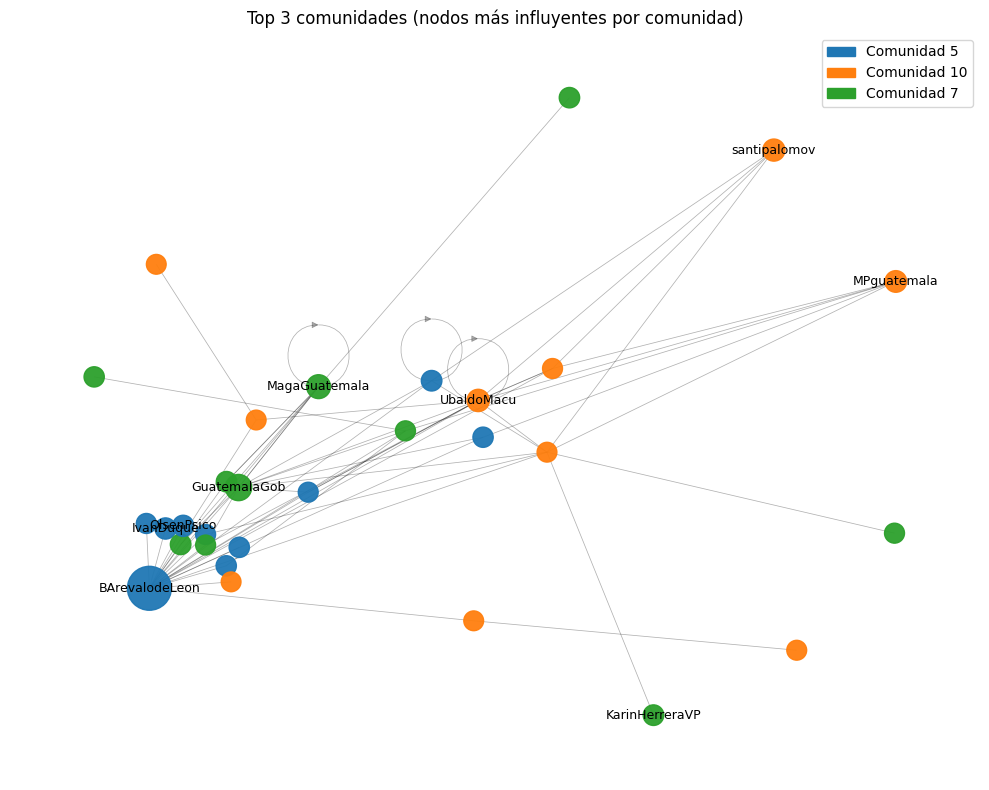

In [80]:
TOP_COMMUNITIES = 3
TOP_NODES_PER_COMM = 10  

top3 = communities_sorted[:TOP_COMMUNITIES]


selected_nodes = []
comm_color_map = {}
palette = plt.cm.tab10.colors  

for idx, (cid, nodes) in enumerate(top3):
    prs = [(n, pagerank.get(n, 0.0)) for n in nodes]
    prs.sort(key=lambda x: x[1], reverse=True)
    top_nodes = [n for n, _ in prs[:TOP_NODES_PER_COMM]]
    selected_nodes.extend(top_nodes)
    for n in top_nodes:
        comm_color_map[n] = idx  # 0,1,2

SG = G.subgraph(selected_nodes).copy()


pos = nx.spring_layout(SG, k=0.7, iterations=200, seed=42)

node_colors = [palette[comm_color_map[n] % len(palette)] for n in SG.nodes()]

pr_values = np.array([pagerank.get(n, 0.0) for n in SG.nodes()])
if pr_values.max() > 0:
    node_sizes = 800 * (pr_values / pr_values.max()) + 200
else:
    node_sizes = np.full(len(SG.nodes()), 300.0)


edge_widths = [0.5 + 2.5*(SG[u][v].get('weight',1.0)/ (df_edges['weight'].max() or 1.0)) for u,v in SG.edges()]

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(SG, pos, width=edge_widths, alpha=0.3, arrows=False)
nx.draw_networkx_nodes(SG, pos, node_color=node_colors, node_size=node_sizes, alpha=0.95)
# Etiquetas solo a los top-3 por comunidad (para no saturar)
labels_nodes = set()
for cid, nodes in top3:
    prs = [(n, pagerank.get(n, 0.0)) for n in nodes]
    prs.sort(key=lambda x: x[1], reverse=True)
    labels_nodes |= set([n for n,_ in prs[:3]])
labels = {n:n for n in SG.nodes() if n in labels_nodes}
nx.draw_networkx_labels(SG, pos, labels=labels, font_size=9)


import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=palette[i], label=f"Comunidad {cid}") 
           for i,(cid,_) in enumerate(top3)]
plt.legend(handles=handles, loc='best')
plt.title("Top 3 comunidades (nodos más influyentes por comunidad)")
plt.axis('off')
plt.tight_layout()
plt.show()


Ya con la visualización, podemos hacer las siguientes conclusiones:


- Hay 3 comunidades relevantes que hablan sobre temas políticos en Guatemala

- La primera (color azul)  podemos decir que se trata de la comunidad del presidente y sus allegados pues podemos ver que hay cuentas como la del mismo presidente Bernardo Arévalo e Iván Duque, un político colombiano que ha demostrado su apoyo a Arévalo en varias ocasiones. 

- La segunda (naranja) podemos decir que son personas que apoyan al presidente pero tienen un poco menos de relevancia, pues aquí encontramos cuentas como UbaldoMacu, su cuenta actualmente está eliminado pero por las menciones que tiene por distintas cuentas se puede notar que esta persona era fiel partidario del partido Semilla y posteaba cosas a favor de ese partido constantemente. También se encuentra Santi Palomo Vila que es secretario de Bernardo Arévalo. Aquí se encuentra el MP pero posiblemente se deba a que los aliados de Bernardo Arévalo mencionaban constantemente a esta institución debido a las polémicas que el presidente ha tenido con esta institución. 

- La última (verde) podría decirse que también son aliados de Bernardo Arévalo pero se enfocan más en publicar anuncios gubernamentales e informar a la población de la gestión del nuevo gobierno, aquí se encuentra la cuenta oficial del gobierno, la vicepresidenta y el Ministerio de Agricultura. 

Ahora vamos a ver cuáles son las cuentas más influyentes, pero queremos ver lo siguiente: 

- Por centralidad: ver cuáles son las cuentas más mencionadas o retweeteadas-
- Por intermediación: quienes son los usuarios que conectan a muchas comunidades diferentes.
- Por centralidad de cercanía: quienes pueden llegar a los demás con menos saltos. 

In [82]:
Gu = G.to_undirected()


degree_centrality = nx.degree_centrality(Gu)
betweenness_centrality = nx.betweenness_centrality(Gu, normalized=True)
closeness_centrality = nx.closeness_centrality(Gu)


centrality_df = pd.DataFrame({
    "node": list(Gu.nodes()),
    "degree": [degree_centrality[n] for n in Gu.nodes()],
    "betweenness": [betweenness_centrality[n] for n in Gu.nodes()],
    "closeness": [closeness_centrality[n] for n in Gu.nodes()]
})


top_degree = centrality_df.sort_values("degree", ascending=False).head(10)
top_betweenness = centrality_df.sort_values("betweenness", ascending=False).head(10)
top_closeness = centrality_df.sort_values("closeness", ascending=False).head(10)


Primero vamos a ver quienes son las cuentas más influyentes por centralidad.

In [83]:
top_degree.head(10)

,node,degree,betweenness,closeness
5,BArevalodeLeon,0.805298,0.886076,0.835021
22,GuatemalaGob,0.197893,0.029389,0.527086
65,UbaldoMacu,0.135014,0.010520,0.503536
222,santipalomov,0.118098,0.007633,0.386886
60,MPguatemala,0.107884,0.008065,0.383148
66,FJimenezmingob,0.089690,0.005550,0.391136
150,__VaderTG,0.076285,0.004649,0.485962
13,CongresoGuate,0.069582,0.003253,0.357567
91,mingobguate,0.066390,0.003507,0.364599
3,USAIDGuate,0.060006,0.001358,0.379528


Vemos que quienes más son mencionados o retweeteados son: 

- El presidente: tiene sentido pues es una figura de gran influencia
- Cuentas oficiales del gobierno: muchas personas mencionan a estas instituciones para quejarse o repostean sus anuncios
- UbaldoMacu: su cuenta ya no existe pero podemos ver que era bastante relevante
- VaderGT: es una cuenta que es opositoria el gobierno, es la 7ma cuenta más popular en base a centralidad por lo que podemos decir que la oposición al gobierno es fuerte. 

Ahora vamos por intermediación

In [84]:
top_betweenness.head(10)

,node,degree,betweenness,closeness
5,BArevalodeLeon,0.805298,0.886076,0.835021
22,GuatemalaGob,0.197893,0.029389,0.527086
347,ElrevoltijoGT,0.030961,0.020088,0.469504
1002,FrJuHeAl,0.007660,0.011193,0.458175
2673,Silencio009,0.007022,0.010946,0.458175
151,HPtAmd,0.006703,0.010598,0.457706
65,UbaldoMacu,0.135014,0.010520,0.503536
60,MPguatemala,0.107884,0.008065,0.383148
222,santipalomov,0.118098,0.007633,0.386886
372,EstacionDobleA,0.012129,0.006910,0.461618


- Sale la cuenta del presidente y las cuentas del gobierno, tiene sentido pues son figuras de autoridad y relevancia y tiene sentido que personas de diferentes comunidades interactuen por medio de posts de estas cuentas.
- Parece que UbaldoMacu fue una cuenta bastante polémica y tiene sentido que varias cmunidades hayan interactuado entre ellas debido a posts polémicos de este usuario
- El RevoltijoGT es una cuenta que se dedica a postear mensajes en contra del gobierno, vemos que no tiene un betweeness tan alto y al buscarlo en la red social twitter, se ve que no es una cuenta con muchos seguidores, posiblemente un post polémico suyo se haya viralizado y eso haya hecho que 2 comunidades diferentes convivieran entre ellas. 
- FrJuHeAi es una cuenta de México que tiene opionesen contra del gobierno actual de México, probablemente un post suyo se haya viralizado a nivel mundial y eso haya provocado que muchas comunidades diferentes hayan interactuado entre ellas. 
- De EstacionDobleA y Silencio2009 no se pudo obtener información.
- El resto de cuentas sn cuentas del gobierno o de instituciones y funcionarios públicos, tiene sentido que provoquen la interacción de muchas comunidades. 

Finalmente, vamos a analizar por cercanía

In [85]:
top_closeness.head(10)

,node,degree,betweenness,closeness
5,BArevalodeLeon,0.805298,0.886076,0.835021
22,GuatemalaGob,0.197893,0.029389,0.527086
65,UbaldoMacu,0.135014,0.010520,0.503536
150,__VaderTG,0.076285,0.004649,0.485962
28,DiariodeCA,0.054261,0.003917,0.480374
37,ElQueNews,0.051069,0.002128,0.478686
12,AGN_noticias,0.043090,0.002163,0.476212
18,Radio_TGW,0.040855,0.000632,0.475345
374,VicenteCarrera_,0.049793,0.003427,0.473621
333,OlsenPsico,0.053942,0.001766,0.473263


- Una vez más, vemos que cuentas del gobierno y de funcionarios públicos aparecen pues al ser figuras con importancia sus mensajes pueden llegar a cualquier tipo de usuario. 
- También aparece UbaldoMacu, todo indica a que en su tiempo fue una cuenta de gran relevancia y que sus mensajes podían llegar a gran cantidad de usuarios diferentes.
-  Aparece VaderGT, podemos notar que mensajes en contra del gobierno pueden llegar con facilidad a gran cantidad de usuarios.
- Hay cuentas de páginas de noticias, tiene  sentido que aparezcan pues hablan sobre temas de actualidad y sirven para mantener informados a los usuarios. 
- Las cuentas de OlsenPsico y VicenteCarrera postean opinones a favor del actual gobierno, hay mucha cuentas afines al gobierno por lo que los mensajes a su favor pueden llegar a gran cantidad de personas. 

Ahora vamos a encontrar a comunidades aisaladas. vamos a vr si hay nodos que están alejados de los demás

In [95]:
# Trabajamos con versión no dirigida para ver conexiones globales
Gu = G.to_undirected()


components = list(nx.connected_components(Gu))
components = sorted(components, key=len, reverse=True)

print(f"Total de subredes encontradas: {len(components)}")
for i, comp in enumerate(components[:10], 1):
    print(f"Subred {i}: {len(comp)} nodos")




Total de subredes encontradas: 1
Subred 1: 3134 nodos


Vemos que todos los nodos están conectados entre sí por lo que no hay subredes en nuestro grafo. 